# MLP — Day-ahead (72h → 24h) — Gaz/Électricité

Objectif : entraîner un MLP (PyTorch) qui prédit :
- **p** : production électrique des GFPP (24 générateurs)
- **g** : injection de gaz des puits (4 wells dans notre cas)

Contexte “opti / day-ahead” :
- **INPUT** = historique des **72 dernières heures** (3 jours)
- **OUTPUT** = trajectoire du **jour suivant (24h)**

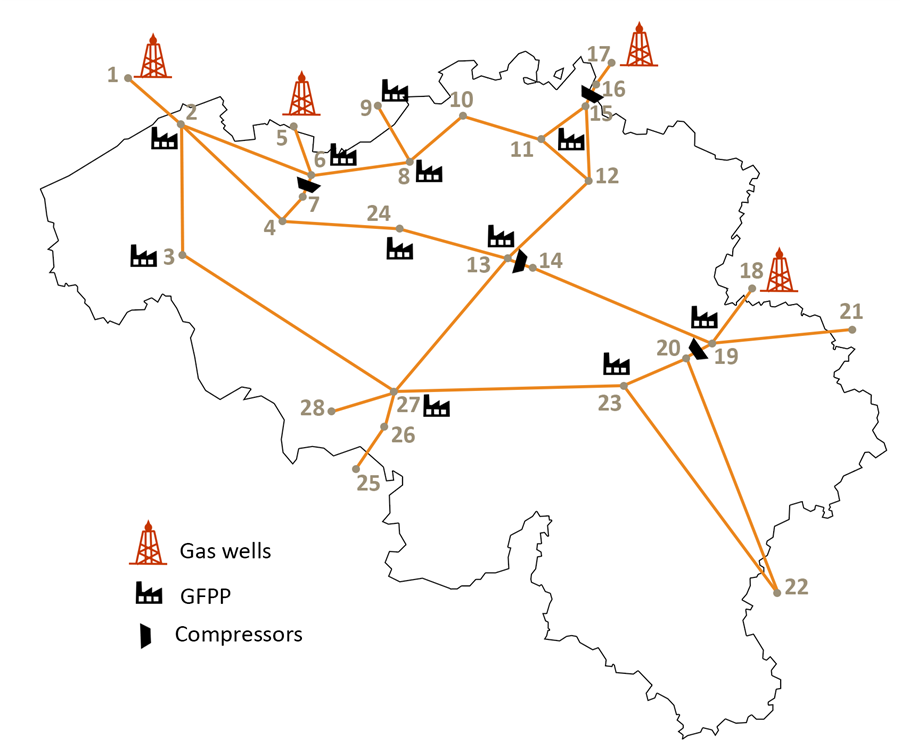

In [314]:
def set_seed(seed: int):
    random.seed(seed) #gen pseudo random
    np.random.seed(seed) #numpy gen pseudo random
    torch.manual_seed(seed) #pytorch gen pseudo random
    torch.cuda.manual_seed_all(seed) #seed on all gpu
    torch.backends.cudnn.deterministic = True #cudnn must used deterministic algorithms
    torch.backends.cudnn.benchmark = False #testing multiple algortithms

set_seed(SEED) #calling function

#keep only numerical values (float/int)
def clean_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    drop_cols = [c for c in df.columns if str(c).startswith("Unnamed")] #delete unnamed columns
    df = df.drop(columns=drop_cols, errors="ignore")#delete unnamed columns
    df = df.select_dtypes(include=[np.number]) #keep if numerical
    return df

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred))) #calculate RMSE

def has_nan(arr: np.ndarray) -> bool:
    return np.isnan(arr).any() #check if NaN detected

def has_inf(arr: np.ndarray) -> bool:
    return np.isinf(arr).any() #check if inf detected

print("Seed set to", SEED) #check seed number


Seed set to 42


In [315]:
def list_months_in_operating_excel_pg(xlsx_path: str) -> List[Tuple[str,str]]: #check musable months
    xls = pd.ExcelFile(xlsx_path) #opening excel file
    sheets = [s.strip() for s in xls.sheet_names] #sheets names in a unique form

    pattern = re.compile(r"^(p|g)-(\d{2})-(\d{4})$") #compiling regular expression
    found: Dict[Tuple[str,str], set] = {} #create empty dictionnary

    for s in sheets:
        m = pattern.match(s) #check if same pattern as regex
        if m:
            kind, month, year = m.group(1), m.group(2), m.group(3) 
            found.setdefault((month, year), set()).add(kind) #tell if pattern found

    months_ok = [(mo, yr) for (mo, yr), kinds in found.items() #avaible months
                 if {"p", "g"}.issubset(kinds)]
    months_ok = sorted(months_ok, key=lambda x: (x[1], x[0])) #sorted in time
    return months_ok

def inspect_operating_excel(xlsx_path: str, max_print=80):
    xls = pd.ExcelFile(xlsx_path) #open excel
    print(f"Nb sheets in {xlsx_path} :", len(xls.sheet_names))
    print("Sheets exemples:", xls.sheet_names[:max_print], "..." if len(xls.sheet_names)>max_print else "")
    months_ok = list_months_in_operating_excel_pg(xlsx_path)
    print("Months with (p,g):", months_ok)
    return months_ok

months_available = inspect_operating_excel(OPERATING_XLSX)


Nb sheets in ./output/Operating_point_final.xlsx : 72
Sheets exemples: ['q-01-2024', 'pr-01-2024', 'g-01-2024', 'p-01-2024', 'NMAE-01-2024', 'Time-01-2024', 'q-02-2024', 'pr-02-2024', 'g-02-2024', 'p-02-2024', 'NMAE-02-2024', 'Time-02-2024', 'q-03-2024', 'pr-03-2024', 'g-03-2024', 'p-03-2024', 'NMAE-03-2024', 'Time-03-2024', 'q-04-2024', 'pr-04-2024', 'g-04-2024', 'p-04-2024', 'NMAE-04-2024', 'Time-04-2024', 'q-05-2024', 'pr-05-2024', 'g-05-2024', 'p-05-2024', 'NMAE-05-2024', 'Time-05-2024', 'q-06-2024', 'pr-06-2024', 'g-06-2024', 'p-06-2024', 'NMAE-06-2024', 'Time-06-2024', 'q-07-2024', 'pr-07-2024', 'g-07-2024', 'p-07-2024', 'NMAE-07-2024', 'Time-07-2024', 'q-08-2024', 'pr-08-2024', 'g-08-2024', 'p-08-2024', 'NMAE-08-2024', 'Time-08-2024', 'q-09-2024', 'pr-09-2024', 'g-09-2024', 'p-09-2024', 'NMAE-09-2024', 'Time-09-2024', 'q-10-2024', 'pr-10-2024', 'g-10-2024', 'p-10-2024', 'NMAE-10-2024', 'Time-10-2024', 'q-11-2024', 'pr-11-2024', 'g-11-2024', 'p-11-2024', 'NMAE-11-2024', 'Time-11-

In [316]:
def read_month_sheet(xls: pd.ExcelFile, sheet: str, expected_cols: int) -> pd.DataFrame:
    df = pd.read_excel(xls, sheet_name=sheet)
    df = clean_numeric_df(df) #keep only numerical
    df = df.iloc[:, :expected_cols] #keep only expected columns
    return df

def load_targets_pg_long(operating_xlsx_path: str,
                         months_to_load: List[Tuple[str,str]]) -> pd.DataFrame:
    
    xls = pd.ExcelFile(operating_xlsx_path) #open excel once
    all_rows = [] #stock dataframe per month

    for (mo, yr) in months_to_load: #for on months
        sh_p = f"p-{mo}-{yr}" #names of the sheet
        sh_g = f"g-{mo}-{yr}"  #names of the sheet

        p = read_month_sheet(xls, sh_p, expected_cols=24) #read sheet
        g = read_month_sheet(xls, sh_g, expected_cols=4)  #read sheet

        n = min(len(p), len(g)) #number of common lines
        p, g = p.iloc[:n], g.iloc[:n] #if data is missing, p and g will still have the same length

        df = pd.concat([p.add_prefix("p_"), g.add_prefix("g_")], axis=1) #rename columns
        df["month"] = mo
        df["year"]  = yr
        df["t"]     = np.arange(n) #time indication

        all_rows.append(df) #add to list

    df_long = pd.concat(all_rows, ignore_index=True) #everything on one dataframe
    return df_long

df_long = load_targets_pg_long(OPERATING_XLSX, months_available)


#multiple checks
print("df_long shape:", df_long.shape)
print("Cols sample:", df_long.columns[:8].tolist(), "...", df_long.columns[-6:].tolist())
print(df_long.head(2))
print("p cols:", sum(str(c).startswith("p_") for c in df_long.columns))
print("g cols:", sum(str(c).startswith("g_") for c in df_long.columns))


df_long shape: (8736, 31)
Cols sample: ['p_0', 'p_1', 'p_2', 'p_3', 'p_4', 'p_5', 'p_6', 'p_7'] ... ['g_1', 'g_2', 'g_3', 'month', 'year', 't']
   p_0  p_1    p_2  p_3  p_4  p_5  p_6  p_7  p_8  p_9  ...      p_21  p_22  \
0  0.0  0.0  19.29  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  4.925508   0.0   
1  0.0  0.0  19.29  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  3.530725   0.0   

   p_23       g_0       g_1       g_2       g_3  month  year  t  
0   0.0  1.862332  0.285714  1.428571  0.285714     01  2024  0  
1   0.0  1.466315  0.535714  1.228996  0.135714     01  2024  1  

[2 rows x 31 columns]
p cols: 24
g cols: 4


In [317]:
def make_continuous_time_index(df_pg_long: pd.DataFrame) -> pd.DataFrame:
    df = df_pg_long.copy()
    df["year_i"] = df["year"].astype(int)
    df["month_i"] = df["month"].astype(int)

    start = pd.to_datetime(df["year_i"].astype(str) + "-" + df["month_i"].astype(str).str.zfill(2) + "-01 00:00:00")
    df["ts"] = start + pd.to_timedelta(df["t"].astype(int), unit="h")

    df = df.sort_values("ts").reset_index(drop=True)
    return df

df_pg_all = make_continuous_time_index(df_long)
print("df_pg_all:", df_pg_all.shape, "| ts monotonic:", df_pg_all["ts"].is_monotonic_increasing)


df_pg_all: (8736, 34) | ts monotonic: True


In [318]:
def load_static_network_vector(gas_network_xlsx: str) -> Dict: 
    xls = pd.ExcelFile(gas_network_xlsx) #new excel opening

    #helpers
    def drop_unnamed(df: pd.DataFrame) -> pd.DataFrame:
        return df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")], errors="ignore") #delete parasite columns

    def to_flat_numeric(df: pd.DataFrame, cols: Optional[List[str]] = None) -> np.ndarray: #put in 1D vector
        if cols is not None:
            cols = [c for c in cols if c in df.columns] #keep columns
            df = df[cols]
        df = df.select_dtypes(include=[np.number]) #delete text
        arr = df.to_numpy().reshape(-1) #flatten
        #fix NaN/inf
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0) #cleaning
        return arr.astype(np.float32)

    #nodes
    nodes = pd.read_excel(xls, "Nodes")
    nodes = drop_unnamed(nodes)
    node_cols_wanted = ["Res_Load_share_%", "Ind_Load_share_%", "Exp_Load_share_%", "Pr_min [bar]", "Pr_max [bar]"]
    node_static = to_flat_numeric(nodes, cols=node_cols_wanted)

    #pipelines
    pipes = pd.read_excel(xls, "Pipelines")
    pipes = drop_unnamed(pipes)
    pipe_cols_wanted = [
        "Natural gas flow constant [MNm3/(bar*h)2]",
        "Compressor factor",
        "High Linepack",
        "Initial linepack [MNm3]",
        "Linepack constant [MNm3/bar]",
        "From node",
        "To node",
    ] #informations on nodes
    pipe_static = to_flat_numeric(pipes, cols=pipe_cols_wanted) #vector in which we put thh informations

    #well
    wells = pd.read_excel(xls, "Well")
    wells = drop_unnamed(wells)
    well_cols_wanted = ["Gmax [MNm3/h]", "Day-ahead offer price [€/MNm3]"]
    well_static = to_flat_numeric(wells, cols=well_cols_wanted) #vector in which we put thh informations

    #topology
    gaswellmap = pd.read_excel(xls, "GasWellMap")
    gaswellmap = drop_unnamed(gaswellmap)
    gaswellmap = to_flat_numeric(gaswellmap, cols=None)

    gfppmap = pd.read_excel(xls, "GFPPMap")
    gfppmap = drop_unnamed(gfppmap)
    gfppmap = to_flat_numeric(gfppmap, cols=None)
    
    #not sure that this is important

    #concat --> every information on a 1D vector
    static_vec = np.concatenate([node_static, pipe_static, well_static, gaswellmap, gfppmap]).astype(np.float32)

    #security NaN/inf
    static_vec = np.nan_to_num(static_vec, nan=0.0, posinf=0.0, neginf=0.0)

    info = {
        "static_vec": static_vec,
        "dims": {
            "node_static": int(node_static.size),
            "pipe_static": int(pipe_static.size),
            "well_static": int(well_static.size),
            "gaswellmap": int(gaswellmap.size),
            "gfppmap": int(gfppmap.size),
            "static_total": int(static_vec.size),
        },
        "cols": {
            "node_cols": [c for c in node_cols_wanted if c in nodes.columns],
            "pipe_cols": [c for c in pipe_cols_wanted if c in pipes.columns],
            "well_cols": [c for c in well_cols_wanted if c in wells.columns],
        }
    }
    #type of dictionnary for our informations in the 1D vector

    #quick check
    print("Static dims:", info["dims"])
    print("NaN in static_vec?", np.isnan(static_vec).any(), "| count:", int(np.isnan(static_vec).sum()))
    print("Inf in static_vec?", np.isinf(static_vec).any(), "| count:", int(np.isinf(static_vec).sum()))

    return info


In [319]:
def inspect_excel_quick(path: str, max_sheets: int = 30, sample_sheet: str = "01-2024"): #sample ==> sheet to read in exemple
    print(f"\n=== Inspect: {path} ===")
    if not os.path.exists(path):
        print("[WARN] File not found.") #error message if not found
        return

    xls = pd.ExcelFile(path)
    print("Nb sheets:", len(xls.sheet_names))
    print("Sheets:", xls.sheet_names[:max_sheets], "..." if len(xls.sheet_names)>max_sheets else "") #to check the sheets

    sh = sample_sheet if sample_sheet in xls.sheet_names else xls.sheet_names[0]
    df = pd.read_excel(path, sheet_name=sh)
    print(f"Sample sheet '{sh}' shape:", df.shape) #sample sheet name + shape (to check)
    print("Columns:", df.columns.tolist()) 
    print("Dtypes head:", df.dtypes.head(10)) #check
    print(df.head(2))

for pth in [GAS_IND_XLSX, GAS_EXP_XLSX, GAS_DIST_XLSX, ELEC_LOAD_XLSX]:
    inspect_excel_quick(pth)
#inspect to check every excel file


=== Inspect: ./input/Gas Cons Ind.xlsx ===
Nb sheets: 13
Sheets: ['01-2024', '02-2024', '03-2024', '04-2024', '05-2024', '06-2024', '07-2024', '08-2024', '09-2024', '10-2024', '11-2024', '12-2024', 'year'] 
Sample sheet '01-2024' shape: (744, 4)
Columns: ['Date Time', 'Physical Flow (kWh)', 'Physical Flow (MNm3)', 'GCV (kwh/Nm3)']
Dtypes head: Date Time               datetime64[ns]
Physical Flow (kWh)              int64
Physical Flow (MNm3)           float64
GCV (kwh/Nm3)                  float64
dtype: object
            Date Time  Physical Flow (kWh)  Physical Flow (MNm3)  \
0 2024-01-01 00:00:00              3941033              0.338141   
1 2024-01-01 01:00:00              3985420              0.342184   

   GCV (kwh/Nm3)  
0         11.655  
1         11.647  

=== Inspect: ./input/Gas Cons Export.xlsx ===
Nb sheets: 13
Sheets: ['01-2024', '02-2024', '03-2024', '04-2024', '05-2024', '06-2024', '07-2024', '08-2024', '09-2024', '10-2024', '11-2024', '12-2024', 'year'] 
Sample she

In [320]:
TIME_CANDIDATES = ["Date Time", "Datetime", "date time", "datetime", "DateTime", "DATE TIME", "DATETIME"] #time candidates

def extract_datetime_and_numeric(df: pd.DataFrame): #to extract the date time of the dataframe
    time_col = None
    for c in df.columns: 
        if str(c) in TIME_CANDIDATES: #check every column names
            time_col = c
            break

    if time_col is None:
        num = df.select_dtypes(include=[np.number]).copy() #check every numerical numbers in every columns
        return None, num

    dt = pd.to_datetime(df[time_col], errors="coerce") #column datetime if founded
    num = df.drop(columns=[time_col], errors="ignore").select_dtypes(include=[np.number]).copy() #other numerical columns
    return dt, num

def load_monthly_consumption(path: str, sheet: str, prefix: str):
    df = pd.read_excel(path, sheet_name=sheet) #read the sheet into datadrame
    dt, num = extract_datetime_and_numeric(df) #separate dt and numerical dataframe
    num = num.add_prefix(prefix) #rename numerical columns
    return dt, num

def load_consumption_inputs_long(df_long: pd.DataFrame,
                                 months: List[Tuple[str,str]],
                                 gas_ind_path: str,
                                 gas_exp_path: str,
                                 gas_dist_path: str,
                                 elec_path: str) -> pd.DataFrame:
   
    cons_blocks = [] #list of one dataframe per month

    for (mo, yr) in months: #construction of the sheet number
        sheet = f"{mo}-{yr}"  #exemple : 01-2024

        dt_ind,  ind_num  = load_monthly_consumption(gas_ind_path,  sheet, prefix="gas_ind__") #date time column + numerical
        dt_exp,  exp_num  = load_monthly_consumption(gas_exp_path,  sheet, prefix="gas_exp__")
        dt_dist, dist_num = load_monthly_consumption(gas_dist_path, sheet, prefix="gas_dist__")

        dt_el, elec_num   = load_monthly_consumption(elec_path, sheet, prefix="elec__")

        # dt reference: elec if present, else ind
        dt_ref = dt_el if dt_el is not None else dt_ind
        if dt_ref is None:
            raise ValueError(f"No datetime column found in consumption files for sheet {sheet}")

        # trunc to the minimal lenght
        n = min(len(dt_ref), len(ind_num), len(exp_num), len(dist_num), len(elec_num))
        dt_ref = dt_ref.iloc[:n] #every dt to the same n
        ind_num, exp_num, dist_num, elec_num = ind_num.iloc[:n], exp_num.iloc[:n], dist_num.iloc[:n], elec_num.iloc[:n] #every num to the same n

        cons_m = pd.concat(
            [ind_num.reset_index(drop=True),
             exp_num.reset_index(drop=True),
             dist_num.reset_index(drop=True),
             elec_num.reset_index(drop=True)],
            axis=1
        ) #every cons in one dataframe

        #temporal key reconstruction
        cons_m["year"]  = dt_ref.dt.year.astype(str)
        cons_m["month"] = dt_ref.dt.month.map(lambda x: f"{x:02d}")
        cons_m["t"]     = np.arange(n)

        #keep only the attended month
        cons_m = cons_m[(cons_m["year"] == str(int(yr))) & (cons_m["month"] == mo)].copy()

        cons_blocks.append(cons_m)

    cons_all = pd.concat(cons_blocks, ignore_index=True) #concat of all months

    # merge sur df_long pour obtenir EXACTEMENT la même longueur/ordre
    cons_df_long = df_long[["year", "month", "t"]].merge(
        cons_all,
        on=["year", "month", "t"],
        how="left", #same lenght df_long and #cons_df_long
        validate="1:1" #no duplicate
    )

    #delete keys
    cons_df_long = cons_df_long.drop(columns=["year", "month", "t"])

    #only cons columns
    cons_df_long = cons_df_long.apply(pd.to_numeric, errors="coerce")

    #replace inf and NaN
    cons_df_long = cons_df_long.replace([np.inf, -np.inf], np.nan)

    #if empty data : interpolation
    cons_df_long = cons_df_long.interpolate(limit_direction="both")
    cons_df_long = cons_df_long.fillna(0.0)

    #double security
    cons_df_long = pd.DataFrame(
        np.nan_to_num(cons_df_long.to_numpy(dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0),
        columns=cons_df_long.columns
    )

    print("cons_df_long shape:", cons_df_long.shape)
    print("Any NaN in cons_df_long?", cons_df_long.isna().any().any())
    return cons_df_long

cons_df_long = load_consumption_inputs_long(
    df_long=df_long,
    months=months_available,
    gas_ind_path=GAS_IND_XLSX,
    gas_exp_path=GAS_EXP_XLSX,
    gas_dist_path=GAS_DIST_XLSX,
    elec_path=ELEC_LOAD_XLSX
)


cons_df_long shape: (8736, 14)
Any NaN in cons_df_long? False


In [321]:
cons_all = cons_df_long.copy()
cons_all["ts"] = df_pg_all["ts"].values
cons_all = cons_all.sort_values("ts").reset_index(drop=True)

print("cons_all:", cons_all.shape, "| ts monotonic:", cons_all["ts"].is_monotonic_increasing)


cons_all: (8736, 15) | ts monotonic: True


In [322]:
static = load_static_network_vector(GAS_NETWORK_XLSX)

Static dims: {'node_static': 140, 'pipe_static': 231, 'well_static': 8, 'gaswellmap': 112, 'gfppmap': 672, 'static_total': 1163}
NaN in static_vec? False | count: 0
Inf in static_vec? False | count: 0


In [323]:
def build_day_ahead_windows_continuous(df_pg_all: pd.DataFrame,
                                       cons_all: pd.DataFrame,
                                       static_vec: np.ndarray,
                                       hist_hours: int = 72,
                                       horizon_hours: int = 24,
                                       use_static: bool = False, stride: int = 24):
    """
    Continuous timeline windows (can cross months).
    INPUT  = 72h past consumption
    OUTPUT = 24h future p and g
    """
    # Targets cols
    Y_p_cols = [c for c in df_pg_all.columns if str(c).startswith("p_")]
    Y_g_cols = [c for c in df_pg_all.columns if str(c).startswith("g_")]

    # X cols = consumption (exclude ts)
    X_cols = [c for c in cons_all.columns if c != "ts"]

    # arrays
    X_dyn = cons_all[X_cols].to_numpy(dtype=np.float32)
    X_dyn = np.nan_to_num(X_dyn, nan=0.0, posinf=0.0, neginf=0.0)

    Y_p = df_pg_all[Y_p_cols].to_numpy(dtype=np.float32)
    Y_g = df_pg_all[Y_g_cols].to_numpy(dtype=np.float32)

    static_vec = np.asarray(static_vec, dtype=np.float32)
    static_vec = np.nan_to_num(static_vec, nan=0.0, posinf=0.0, neginf=0.0)

    ts = df_pg_all["ts"].to_numpy()

    # Gap detection (skip windows crossing gaps)
    dt = np.diff(ts).astype("timedelta64[h]").astype(int)
    gap_positions = np.where(dt != 1)[0]
    has_gaps = len(gap_positions) > 0
    if has_gaps:
        print(f"[WARN] Found {len(gap_positions)} gaps where ts step != 1 hour. Windows crossing gaps will be skipped.")

    X_list, y_list, win_ts = [], [], []
    N = len(df_pg_all)

    for t0 in range(hist_hours, N - horizon_hours + 1, STRIDE):
        if has_gaps:
            start = t0 - hist_hours
            end = t0 + horizon_hours - 1
            if np.any(dt[start:end] != 1):
                continue

        # X
        x_hist = X_dyn[t0 - hist_hours:t0, :]      # (72, D)
        x_flat = x_hist.reshape(-1)                # (72*D,)

        if use_static:
            x_flat = np.concatenate([x_flat, static_vec], axis=0)

        # y
        y_p_24 = Y_p[t0:t0 + horizon_hours, :].reshape(-1)  # 576
        y_g_24 = Y_g[t0:t0 + horizon_hours, :].reshape(-1)  # 96
        y = np.concatenate([y_p_24, y_g_24], axis=0)         # 672

        X_list.append(x_flat)
        y_list.append(y)
        win_ts.append(ts[t0])  # forecast start timestamp

    X = np.stack(X_list).astype(np.float32)
    y = np.stack(y_list).astype(np.float32)
    win_ts = np.array(win_ts)

    meta = {
        "hist_hours": hist_hours,
        "horizon_hours": horizon_hours,
        "X_dim": int(X.shape[1]),
        "y_dim": int(y.shape[1]),
        "p_dim": int(horizon_hours * len(Y_p_cols)),
        "g_dim": int(horizon_hours * len(Y_g_cols)),
        "dyn_per_hour": int(len(X_cols)),
        "static_dim": int(static_vec.size),
    }
    return X, y, win_ts, meta

X, y, win_ts, meta = build_day_ahead_windows_continuous(
    df_pg_all=df_pg_all,
    cons_all=cons_all,
    static_vec=static["static_vec"],
    hist_hours=HIST_HOURS,
    horizon_hours=HORIZON_HOURS,
    use_static=False, stride = STRIDE
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Meta:", meta)
print("First ts:", win_ts[0], "| Last ts:", win_ts[-1])
print("NaN in X?", np.isnan(X).any(), "| NaN in y?", np.isnan(y).any())



[WARN] Found 2 gaps where ts step != 1 hour. Windows crossing gaps will be skipped.
X shape: (355, 1008)
y shape: (355, 672)
Meta: {'hist_hours': 72, 'horizon_hours': 24, 'X_dim': 1008, 'y_dim': 672, 'p_dim': 576, 'g_dim': 96, 'dyn_per_hour': 14, 'static_dim': 1163}
First ts: 2024-01-04T00:00:00.000000000 | Last ts: 2024-12-31T00:00:00.000000000
NaN in X? False | NaN in y? False


In [324]:
split_ts = pd.Timestamp("2024-10-01 00:00:00")

train_mask = win_ts < np.datetime64(split_ts)
val_mask   = win_ts >= np.datetime64(split_ts)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)



X_train: (267, 1008) y_train: (267, 672)
X_val  : (88, 1008) y_val  : (88, 672)


In [325]:
#scaling dataset functions

scaler_X = StandardScaler() #same variance and mean because different data (to check)
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)

y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)

joblib.dump(scaler_X, os.path.join(OUT_DIR, "scaler_X.pkl")) #put the scaled values in our file OUT_DIR
joblib.dump(scaler_y, os.path.join(OUT_DIR, "scaler_y.pkl"))

print("Scaled shapes:", X_train_s.shape, y_train_s.shape)
print("Any NaN scaled X?", np.isnan(X_train_s).any(), np.isnan(X_val_s).any())
print("Any NaN scaled y?", np.isnan(y_train_s).any(), np.isnan(y_val_s).any())


Scaled shapes: (267, 1008) (267, 672)
Any NaN scaled X? False False
Any NaN scaled y? False False


In [326]:
#the goal is to put numpy values into values featable with PyTorch

class NumpyDataset(Dataset):
    def __init__(self, X_np: np.ndarray, y_np: np.ndarray):
        self.X = torch.from_numpy(X_np).float() #tensor sharing the memory with numy
        self.y = torch.from_numpy(y_np).float()

    def __len__(self):
        return self.X.shape[0] #send the number of lines

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx] #to return vector

#we create two NumpYDataset objects
train_ds = NumpyDataset(X_train_s.astype(np.float32), y_train_s.astype(np.float32)) #we create two NumpYDataset objects
val_ds   = NumpyDataset(X_val_s.astype(np.float32),   y_val_s.astype(np.float32))

#DataLoader create batches from the dataset
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape, "Batch y:", yb.shape)


Batch X: torch.Size([32, 1008]) Batch y: torch.Size([32, 672])


In [327]:
class MLP(nn.Module): #pytorch model class
    def __init__(self, input_dim: int, output_dim: int,
                 hidden_sizes: List[int], dropout: float = 0.2): #construction of the model
        super().__init__() #construct of the nn.Module
        layers = [] 
        prev = input_dim #dimension of the first layer
        for h in hidden_sizes: #1024 1024 512
            layers.append(nn.Linear(prev, h)) #entry and bias
            layers.append(nn.ReLU()) #activation function
            layers.append(nn.Dropout(dropout)) #add a dropout after ReLu
            prev = h #prev for the next layer
        layers.append(nn.Linear(prev, output_dim)) #output layer
        self.net = nn.Sequential(*layers) #to chain all the layers

    def forward(self, x): #how the model calculate from the entry
        return self.net(x)

input_dim = X_train_s.shape[1] 
output_dim = y_train_s.shape[1]  

model = MLP(input_dim=input_dim, output_dim=output_dim,
            hidden_sizes=HIDDEN_SIZES, dropout=DROPOUT).to(DEVICE) #concrete object creation and sending on GPU/CPU

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad) #computing model parameters
print("Model parameters:", n_params)


Model parameters: 2952352


In [328]:
huber = torch.nn.SmoothL1Loss(beta=1.0)
def loss_huber_dyn_ptotal(pred, target, horizon=24, n_p=24, n_g=4,
                          lambda_dyn=0.5, alpha_ptotal=1.0):
    """
    pred, target: (B, out_dim) avec out_dim = horizon*(n_p+n_g) = 24*28 = 672
    Organisation par heure: [p(24) | g(4)] répété sur 24 heures.
    """
    B = pred.size(0)
    F = n_p + n_g

    # reshape -> (B, H, F)
    pred_3d = pred.view(B, horizon, F)
    targ_3d = target.view(B, horizon, F)

    # 1) Huber pointwise sur toutes les sorties
    # (on peut l'appliquer sur les tensors flatten directement)
    loss_point = huber(pred, target)

    # 2) Terme dynamique : Huber sur les différences horaires
    dp = pred_3d[:, 1:, :] - pred_3d[:, :-1, :]
    dt = targ_3d[:, 1:, :] - targ_3d[:, :-1, :]
    loss_dyn = huber(dp, dt)

    # 3) Terme p_total : somme des 24 GFPP à chaque heure
    pred_p = pred_3d[:, :, :n_p]      # (B, H, 24)
    targ_p = targ_3d[:, :, :n_p]
    pred_ptot = pred_p.sum(dim=2)     # (B, H)
    targ_ptot = targ_p.sum(dim=2)

    loss_ptot = huber(pred_ptot, targ_ptot)

    # Loss finale
    return loss_point + lambda_dyn * loss_dyn + alpha_ptotal * loss_ptot

In [330]:
criterion = nn.MSELoss() #loss function
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4) #optimizer : automatic step for parameters

# Scheduler : reduce LR automatically when validation loss stops improving
# Here : if val_loss doesn't improve for 5 epochs -> LR = LR * 0.5 (min LR = 1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",      # we want to minimize val_loss
    factor=0.5,      # multiply LR by 0.5 when plateau
    patience=5,      # wait 5 epochs without improvement
    threshold=1e-6,  # minimal improvement to be considered as improvement
    min_lr=1e-7,     # do not go below this LR
    verbose=True     # prints when LR is reduced
)

threshold=1e-6
best_val = float("inf")
pat = PATIENCE
best_path = os.path.join(OUT_DIR, "best_model.pt") #path when we save our best model

def run_eval_loss(model, loader):
    model.eval() #switch the model into evaluation mode
    #losses = []
    total_loss = 0.0
    total_n = 0
    with torch.no_grad(): #stop the gradient calculation
        for xb, yb in loader: #for validation batches
            xb, yb = xb.to(DEVICE), yb.to(DEVICE) #send data to GPU or CPU
            pred = model(xb) #prediction forward pass
            #loss = criterion(pred, yb) #MSE calculation
            #loss = loss_with_dynamics(pred, yb, horizon=24, lambda_dyn=LAMBDA_DYN)
            loss = loss_huber_dyn_ptotal(pred, yb,horizon=24, n_p=24, n_g=4,lambda_dyn=LAMBDA_DYN,alpha_ptotal=ALPHA_PTOTAL)
            #losses.append(loss.item()) #.item() ==> scalar tensor into float
            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_n += bs
    #return float(np.mean(losses)) if losses else float("inf")
    return total_loss / total_n if total_n > 0 else float("inf")

lr_history = []

for epoch in range(1, EPOCHS + 1):
    model.train() #training mode 
    total_train_loss = 0.0
    total_train_n = 0
    train_losses = [] #batch train losses list
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad() #put to zero accumulated gradients
        pred = model(xb) #forward pass
        #loss = criterion(pred, yb) #calculation MSE
        #loss = loss_with_dynamics(pred, yb, horizon=24, lambda_dyn=LAMBDA_DYN)
        loss = loss_huber_dyn_ptotal(pred, yb,horizon=24, n_p=24, n_g=4,lambda_dyn=LAMBDA_DYN,alpha_ptotal=ALPHA_PTOTAL)
        bs = xb.size(0)
        total_train_loss += loss.item() * bs
        total_train_n += bs
        loss.backward() #back propagation
        optimizer.step() #new weights (from Adam and loss)

        train_losses.append(loss.item()) #stock float of the batch

    #train_loss = float(np.mean(train_losses)) #mean loss on all the batches
    train_loss = total_train_loss / total_train_n if total_train_n > 0 else float("inf")

    # ... DANS LA BOUCLE for xb, yb in train_loader:
    bs = xb.size(0)
    total_train_loss += loss.item() * bs
    total_train_n += bs

    # ... APRÈS la boucle train_loader:
    train_loss = total_train_loss / total_train_n
    val_loss = run_eval_loss(model, val_loader) #mean loss on validation

    # Scheduler step (ReduceLROnPlateau must see the metric we monitor, here val_loss)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    lr_history.append(current_lr)

    if epoch > 20:
        if val_loss < best_val - threshold: #minimal amelioration treshold
            best_val = val_loss
            pat = PATIENCE #patience to maximum
            torch.save(model.state_dict(), best_path) #new best model
        else:
            pat -= 1

        if pat <= 0:
            print("Early stopping triggered.")
            break

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | train {train_loss:.5f} | val {val_loss:.5f} | best {best_val:.5f} | patience {pat} | lr {current_lr:.6g}")

model.load_state_dict(torch.load(best_path, map_location=DEVICE))
print("Loaded best model from:", best_path)
print("Best val loss:", best_val)



Epoch 001 | train 7.98973 | val 10.61324 | best inf | patience 15 | lr 0.0001
Epoch 005 | train 6.69483 | val 10.64382 | best inf | patience 15 | lr 0.0001
Epoch 010 | train 5.92119 | val 10.65453 | best inf | patience 15 | lr 0.0001
Epoch 015 | train 5.59944 | val 10.12696 | best inf | patience 15 | lr 0.0001
Epoch 020 | train 4.87845 | val 9.89801 | best inf | patience 15 | lr 5e-05
Epoch 025 | train 4.57516 | val 9.89413 | best 9.82639 | patience 14 | lr 5e-05
Epoch 030 | train 4.33600 | val 9.91481 | best 9.82639 | patience 9 | lr 2.5e-05
Epoch 035 | train 4.33350 | val 10.01795 | best 9.82639 | patience 4 | lr 2.5e-05
Early stopping triggered.
Loaded best model from: ./runs_mlp_day_ahead_CONSO_STATIC\best_model.pt
Best val loss: 9.826385064558549


C:\Users\yoans\AppData\Local\Temp\ipykernel_23164\3724351082.py:96: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=DE

In [331]:
xb_tr, yb_tr = next(iter(train_loader))
xb_va, yb_va = next(iter(val_loader))

print("X train mean/std:", xb_tr.mean().item(), xb_tr.std().item())
print("X val   mean/std:", xb_va.mean().item(), xb_va.std().item())

print("y train mean/std:", yb_tr.mean().item(), yb_tr.std().item())
print("y val   mean/std:", yb_va.mean().item(), yb_va.std().item())

X train mean/std: -0.11833196878433228 0.9093278050422668
X val   mean/std: -0.035970307886600494 0.8012473583221436
y train mean/std: -0.01697760820388794 0.9297045469284058
y val   mean/std: 0.10188685357570648 1.0214531421661377


In [332]:
# reload best
model.load_state_dict(torch.load(best_path, map_location=DEVICE)) #charging best path weights
model.eval() #put this weights in our model
# predict val
preds_s = [] #stock predictions
with torch.no_grad(): #desactivate gradients
    for xb, _ in val_loader: #for validation batches (no yb)
        xb = xb.to(DEVICE) #send into CPU/GPU
        preds_s.append(model(xb).cpu().numpy()) #conversion, add batch to list,..
y_val_pred_s = np.vstack(preds_s) #vertically sotcked batches

# inverse scale to real units
y_val_true = scaler_y.inverse_transform(y_val_s)
y_val_pred = scaler_y.inverse_transform(y_val_pred_s)

print("Val loss (scaled space):", best_val)

H = HORIZON_HOURS
P = 24
G = 4

def split_pg(y_flat):
    y_p = y_flat[:, :H*P].reshape(-1, H, P) #structurated sensor p (24h×24 GFPP)
    y_g = y_flat[:, H*P:].reshape(-1, H, G) #structurated sensor g (24h×4 wells)
    return y_p, y_g 

p_true, g_true = split_pg(y_val_true) #true
p_pred, g_pred = split_pg(y_val_pred) #prediction

# MAE / RMSE
p_mae = mean_absolute_error(p_true.reshape(-1), p_pred.reshape(-1)) #global MAE on everything (hours,GFFP)
p_rmse = rmse(p_true.reshape(-1), p_pred.reshape(-1)) #global RMSE on everything (hours,GFFP)
g_mae = mean_absolute_error(g_true.reshape(-1), g_pred.reshape(-1)) #global MAE on everything (hours,Wells)
g_rmse = rmse(g_true.reshape(-1), g_pred.reshape(-1)) #global RMSE on everything (hours,Wells)

# NMAE 
p_nmae = float(np.mean(np.abs(p_true - p_pred)) / (np.mean(np.abs(p_true)) + 1e-9))
g_nmae = float(np.mean(np.abs(g_true - g_pred)) / (np.mean(np.abs(g_true)) + 1e-9))

print("\nVAL METRICS (real units, y denormalized) :")
print("p  MAE :", p_mae, "RMSE:", p_rmse)
print("g  MAE :", g_mae, "RMSE:", g_rmse)
print("p  NMAE:", p_nmae)
print("g  NMAE:", g_nmae)

# export quick sample
sample_csv = os.path.join(OUT_DIR, "val_preds_sample.csv")
sample_idx = np.arange(min(50, len(y_val_true)))
pd.DataFrame({
    "p_abs_err_mean": np.mean(np.abs(p_true[sample_idx] - p_pred[sample_idx]), axis=(1,2)),
    "g_abs_err_mean": np.mean(np.abs(g_true[sample_idx] - g_pred[sample_idx]), axis=(1,2)),
}).to_csv(sample_csv, index=False)
print("Exported sample window MAEs to:", sample_csv)



Val loss (scaled space): 9.826385064558549

VAL METRICS (real units, y denormalized) :
p  MAE : 0.9437226057052612 RMSE: 2.1692257098343406
g  MAE : 0.29079508781433105 RMSE: 0.37564198853830094
p  NMAE: 0.3709683418273926
g  NMAE: 0.23673543334007263
Exported sample window MAEs to: ./runs_mlp_day_ahead_CONSO_STATIC\val_preds_sample.csv


C:\Users\yoans\AppData\Local\Temp\ipykernel_23164\2599108768.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=DEV

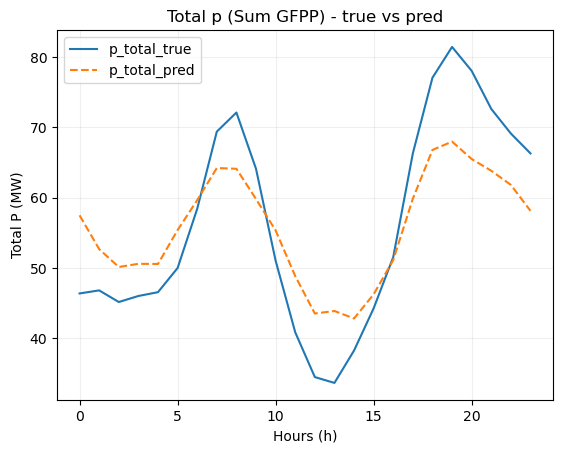

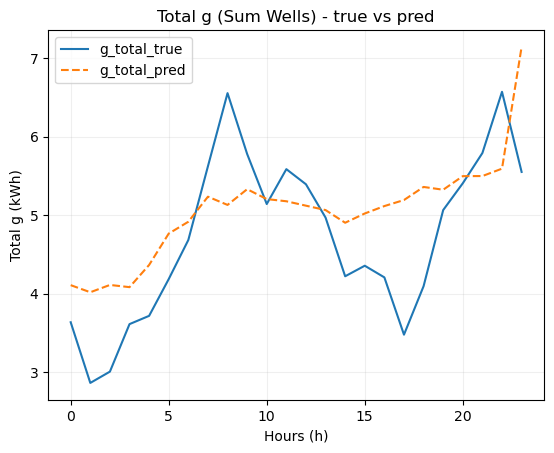

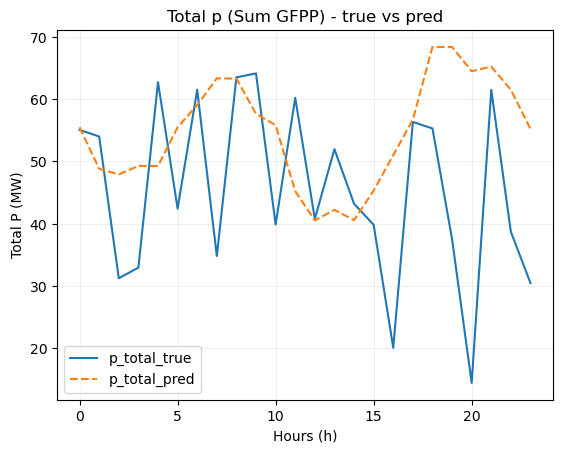

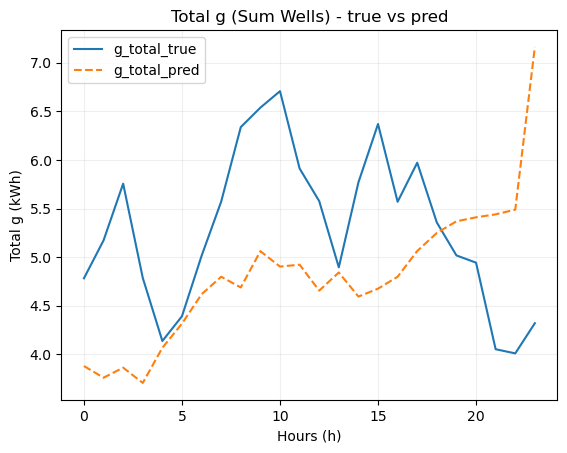

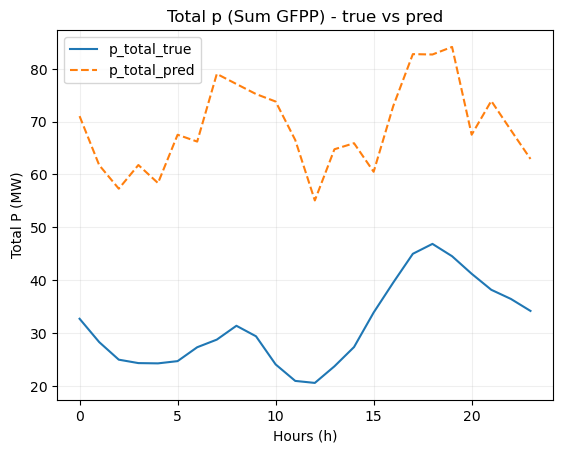

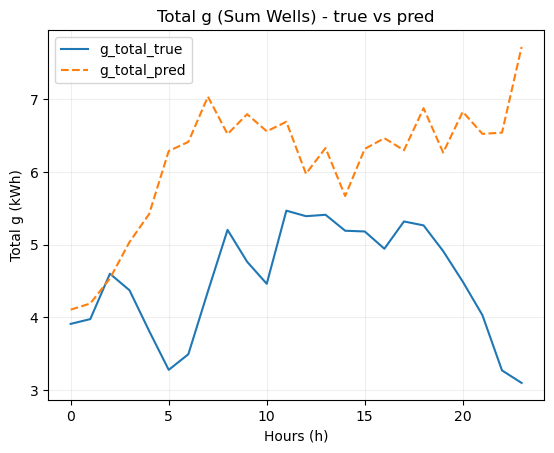

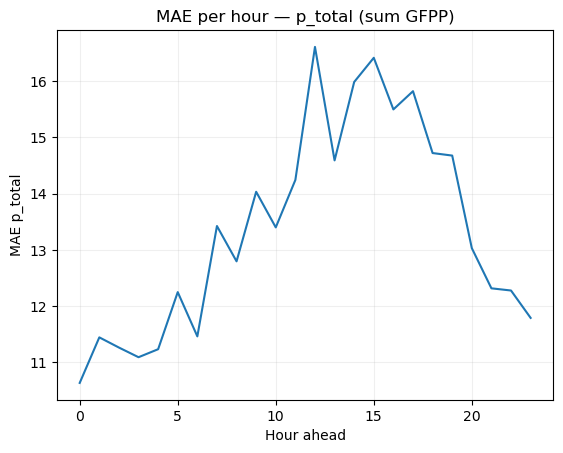

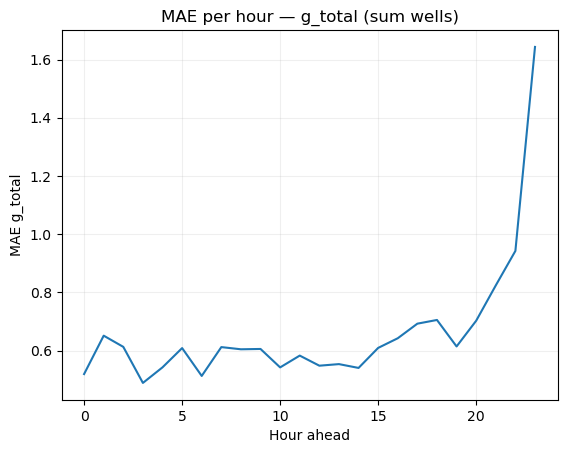

Roughness p_total (true mean / pred mean): 5.129568576812744 4.594528675079346
Roughness g_total (true mean / pred mean): 0.45144227147102356 0.287569522857666

TOTAL METRICS (agrégés) :
p_total MAE: 13.37587833404541 RMSE: 16.452146530151367
g_total MAE: 0.6623306274414062 RMSE: 0.886279821395874


In [333]:
import numpy as np
import matplotlib.pyplot as plt

H = 24
P = 24
G = 4

def split_pg(y_flat):
    y_p = y_flat[:, :H*P].reshape(-1, H, P)      # (N, 24, 24)
    y_g = y_flat[:, H*P:].reshape(-1, H, G)      # (N, 24, 4)
    return y_p, y_g


p_true, g_true = split_pg(y_val_true)
p_pred, g_pred = split_pg(y_val_pred)


# total elec prod = sum on all GFFP
p_tot_true = np.sum(p_true, axis=2)   # (N, 24)
p_tot_pred = np.sum(p_pred, axis=2)   # (N, 24)

# total gaz prod = sum on all Wells
g_tot_true = np.sum(g_true, axis=2)   # (N, 24)
g_tot_pred = np.sum(g_pred, axis=2)   # (N, 24)


# Plots true vs pred (few exemples)

np.random.seed(0)
idxs = np.random.choice(len(p_true), size=min(3, len(p_true)), replace=False)

for idx in idxs:
    i=1
    plt.figure()
    plt.plot(p_tot_true[idx], label="p_total_true")
    plt.plot(p_tot_pred[idx], linestyle="--", label="p_total_pred")
    plt.title(f"Total p (Sum GFPP) - true vs pred")
    plt.xlabel("Hours (h)")
    plt.ylabel("Total P (MW)")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(g_tot_true[idx], label="g_total_true")
    plt.plot(g_tot_pred[idx], linestyle="--", label="g_total_pred")
    plt.title(f"Total g (Sum Wells) - true vs pred")
    plt.xlabel("Hours (h)")
    plt.ylabel("Total g (kWh)")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()
    i=i+1


# MAE per hour
mae_p_tot_hour = np.mean(np.abs(p_tot_true - p_tot_pred), axis=0)  # (24,)
mae_g_tot_hour = np.mean(np.abs(g_tot_true - g_tot_pred), axis=0)  # (24,)

plt.figure()
plt.plot(mae_p_tot_hour)
plt.title("MAE per hour — p_total (sum GFPP)")
plt.xlabel("Hour ahead")
plt.ylabel("MAE p_total")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure()
plt.plot(mae_g_tot_hour)
plt.title("MAE per hour — g_total (sum wells)")
plt.xlabel("Hour ahead")
plt.ylabel("MAE g_total")
plt.grid(True, alpha=0.2)
plt.show()


# Roughness on totals (oscillations)
def roughness_1d(x):  # x: (N, H)
    return np.mean(np.abs(x[:, 1:] - x[:, :-1]), axis=1)  # (N,)

r_p_true = roughness_1d(p_tot_true)
r_p_pred = roughness_1d(p_tot_pred)
r_g_true = roughness_1d(g_tot_true)
r_g_pred = roughness_1d(g_tot_pred)

print("Roughness p_total (true mean / pred mean):", float(r_p_true.mean()), float(r_p_pred.mean()))
print("Roughness g_total (true mean / pred mean):", float(r_g_true.mean()), float(r_g_pred.mean()))

if r_p_pred.mean() > 1.5 * r_p_true.mean():
    print("[WARN] p_total predictions look too oscillatory vs true (roughness too high).")
if r_g_pred.mean() > 1.5 * r_g_true.mean():
    print("[WARN] g_total predictions look too oscillatory vs true (roughness too high).")

# global score
p_tot_mae = float(np.mean(np.abs(p_tot_true - p_tot_pred)))
g_tot_mae = float(np.mean(np.abs(g_tot_true - g_tot_pred)))

p_tot_rmse = float(np.sqrt(np.mean((p_tot_true - p_tot_pred) ** 2)))
g_tot_rmse = float(np.sqrt(np.mean((g_tot_true - g_tot_pred) ** 2)))

print("\nTOTAL METRICS (agrégés) :")
print("p_total MAE:", p_tot_mae, "RMSE:", p_tot_rmse)
print("g_total MAE:", g_tot_mae, "RMSE:", g_tot_rmse)


In [334]:
print("true min/mean/max:", p_tot_true.min(), p_tot_true.mean(), p_tot_true.max())
print("pred min/mean/max:", p_tot_pred.min(), p_tot_pred.mean(), p_tot_pred.max())

true min/mean/max: 14.204314 61.054653 95.74397
pred min/mean/max: 31.75917 58.39812 87.82573


In [335]:
import numpy as np
import matplotlib.pyplot as plt

H = HORIZON_HOURS
P = 24
G = 4

def split_pg(y_flat, H=24, P=24, G=4):
    """
    y_flat: (N, 672) avec y = [p_flat (H*P), g_flat (H*G)]
    Retour:
      p: (N, H, P)
      g: (N, H, G)
    """
    y_p = y_flat[:, :H*P].reshape(-1, H, P)
    y_g = y_flat[:, H*P:].reshape(-1, H, G)
    return y_p, y_g

def mae(a, b):
    return float(np.mean(np.abs(a - b)))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def safe_mean_abs(x, eps=1e-9):
    return float(np.mean(np.abs(x)) + eps)


In [336]:
# MAE/RMSE globaux sur tous les points (toutes fenêtres, toutes heures, toutes unités)
p_mae = mae(p_true, p_pred)
p_rmse = rmse(p_true, p_pred)

g_mae = mae(g_true, g_pred)
g_rmse = rmse(g_true, g_pred)

# MAE / mean_abs (%)  -> "erreur relative simple"
p_mae_pct = 100.0 * p_mae / safe_mean_abs(p_true)
g_mae_pct = 100.0 * g_mae / safe_mean_abs(g_true)

print("=== GLOBAL METRICS (all points) ===")
print(f"p: MAE={p_mae:.6f} | RMSE={p_rmse:.6f} | MAE/mean_abs={p_mae_pct:.3f}%")
print(f"g: MAE={g_mae:.6f} | RMSE={g_rmse:.6f} | MAE/mean_abs={g_mae_pct:.3f}%")


=== GLOBAL METRICS (all points) ===
p: MAE=0.943723 | RMSE=2.169226 | MAE/mean_abs=37.097%
g: MAE=0.290795 | RMSE=0.375642 | MAE/mean_abs=23.674%


In [337]:
# Totaux par heure
p_tot_true = np.sum(p_true, axis=2)  # (N, H)
p_tot_pred = np.sum(p_pred, axis=2)

g_tot_true = np.sum(g_true, axis=2)  # (N, H)
g_tot_pred = np.sum(g_pred, axis=2)

p_tot_mae  = mae(p_tot_true, p_tot_pred)
p_tot_rmse = rmse(p_tot_true, p_tot_pred)
g_tot_mae  = mae(g_tot_true, g_tot_pred)
g_tot_rmse = rmse(g_tot_true, g_tot_pred)

p_tot_mae_pct = 100.0 * p_tot_mae / safe_mean_abs(p_tot_true)
g_tot_mae_pct = 100.0 * g_tot_mae / safe_mean_abs(g_tot_true)

print("\n=== AGGREGATED TOTALS (sum over units, per hour) ===")
print(f"p_total: MAE={p_tot_mae:.6f} | RMSE={p_tot_rmse:.6f} | MAE/mean_abs={p_tot_mae_pct:.3f}%")
print(f"g_total: MAE={g_tot_mae:.6f} | RMSE={g_tot_rmse:.6f} | MAE/mean_abs={g_tot_mae_pct:.3f}%")



=== AGGREGATED TOTALS (sum over units, per hour) ===
p_total: MAE=13.375878 | RMSE=16.452147 | MAE/mean_abs=21.908%
g_total: MAE=0.662331 | RMSE=0.886280 | MAE/mean_abs=13.480%


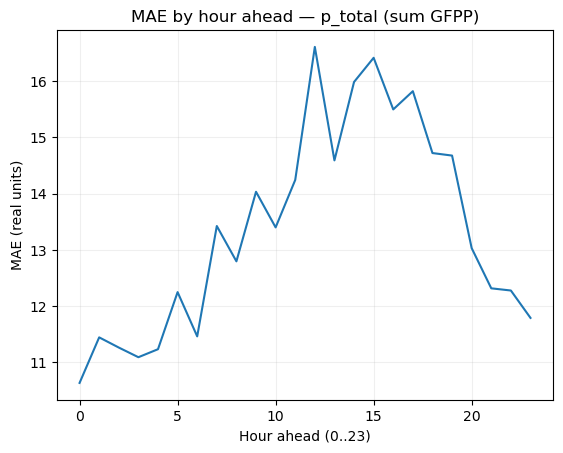

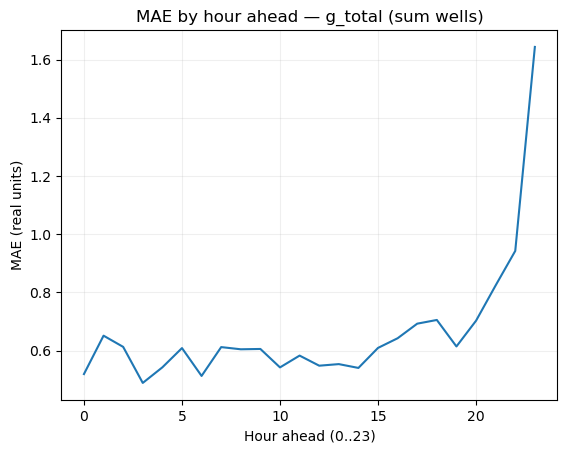

In [338]:
# MAE par heure (sur p_total et g_total)
mae_p_tot_hour = np.mean(np.abs(p_tot_true - p_tot_pred), axis=0)  # (H,)
mae_g_tot_hour = np.mean(np.abs(g_tot_true - g_tot_pred), axis=0)  # (H,)

plt.figure()
plt.plot(np.arange(H), mae_p_tot_hour)
plt.title("MAE by hour ahead — p_total (sum GFPP)")
plt.xlabel("Hour ahead (0..23)")
plt.ylabel("MAE (real units)")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure()
plt.plot(np.arange(H), mae_g_tot_hour)
plt.title("MAE by hour ahead — g_total (sum wells)")
plt.xlabel("Hour ahead (0..23)")
plt.ylabel("MAE (real units)")
plt.grid(True, alpha=0.2)
plt.show()


In [339]:
def roughness_1d(x_2d):  # x_2d: (N, H)
    return np.mean(np.abs(x_2d[:, 1:] - x_2d[:, :-1]), axis=1)  # (N,)

r_p_true = roughness_1d(p_tot_true)
r_p_pred = roughness_1d(p_tot_pred)
r_g_true = roughness_1d(g_tot_true)
r_g_pred = roughness_1d(g_tot_pred)

print("Roughness p_total (true mean / pred mean):", float(r_p_true.mean()), float(r_p_pred.mean()))
print("Roughness g_total (true mean / pred mean):", float(r_g_true.mean()), float(r_g_pred.mean()))

if r_p_pred.mean() > 1.5 * r_p_true.mean():
    print("[WARN] p_total predictions look too oscillatory vs true (roughness too high).")
if r_g_pred.mean() > 1.5 * r_g_true.mean():
    print("[WARN] g_total predictions look too oscillatory vs true (roughness too high).")


Roughness p_total (true mean / pred mean): 5.129568576812744 4.594528675079346
Roughness g_total (true mean / pred mean): 0.45144227147102356 0.287569522857666


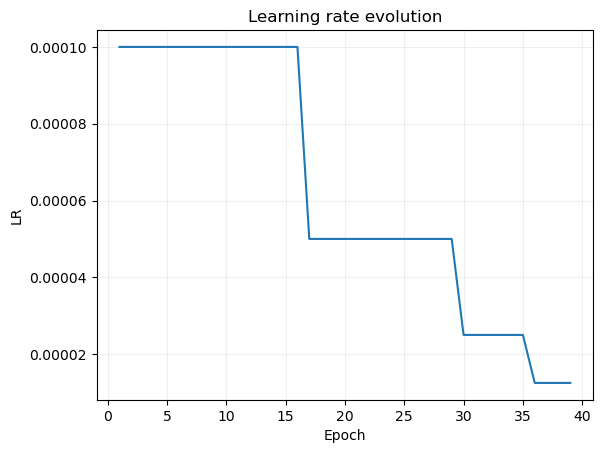

In [340]:
plt.figure()
plt.plot(np.arange(1, len(lr_history)+1), lr_history)
plt.title("Learning rate evolution")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True, alpha=0.2)
plt.show()


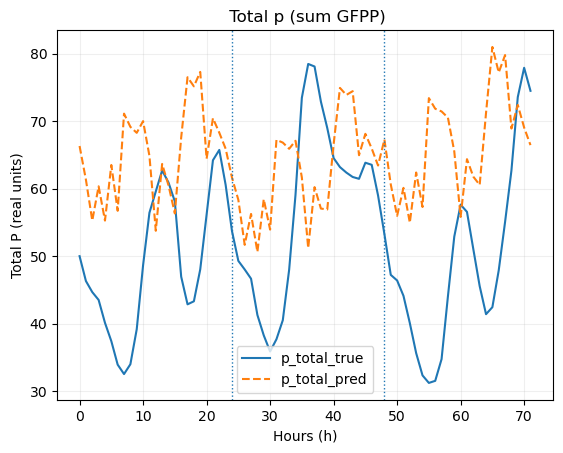

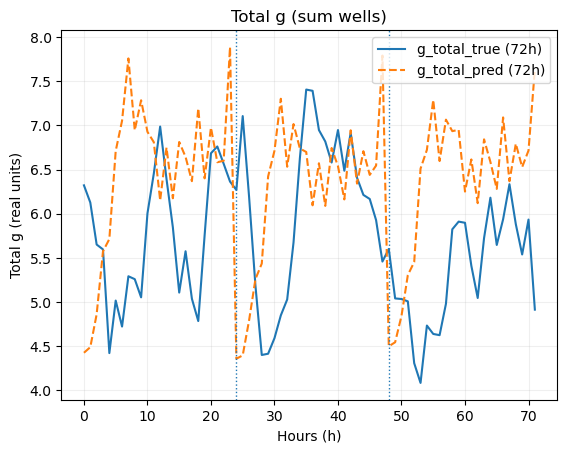

Done. You now have:
p_true_72 shape: (72, 24) | p_pred_72 shape: (72, 24)
g_true_72 shape: (72, 4) | g_pred_72 shape: (72, 4)


In [341]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# =========================
# Rolling day-ahead prediction: 72h = 3 * 24h
# =========================

# ---- settings you can change ----
START_TS = None   # e.g. "2024-02-01 00:00:00" ; if None -> we take a default index
START_INDEX = 500 # used if START_TS is None (index in df_pg_all timeline)
N_DAYS = 3        # 3 days => 72h
H = HORIZON_HOURS # 24
HIST = HIST_HOURS # 72
P = 24
G = 4

use_static = False

# ---------- helpers ----------
def build_X_for_t0(t0_idx, cons_all, static_vec, dyn_per_hour, HIST=72, use_static=False):
    """
    Build one model input X corresponding to history [t0-72 .. t0-1] for a given t0 index
    """
    # take the 72h history of consumption
    x_hist = cons_all.iloc[t0_idx - HIST:t0_idx].drop(columns=["ts"], errors="ignore").to_numpy(dtype=np.float32)
    assert x_hist.shape[0] == HIST, "Not enough history points for this t0"
    assert x_hist.shape[1] == dyn_per_hour, f"dyn_per_hour mismatch: {x_hist.shape[1]} vs {dyn_per_hour}"
    x_flat = x_hist.reshape(-1)  # (72*dyn_per_hour,)

    if use_static:
        x_flat = np.concatenate([x_flat, static_vec.astype(np.float32)], axis=0)

    return x_flat.astype(np.float32)

def get_true_pg_for_horizon(t0_idx, df_pg_all, H=24):
    """
    Extract true p and g for horizon [t0 .. t0+H-1] from df_pg_all (real units)
    Returns:
      p_true: (H,P), g_true:(H,G)
    """
    Y_p_cols = [c for c in df_pg_all.columns if str(c).startswith("p_")]
    Y_g_cols = [c for c in df_pg_all.columns if str(c).startswith("g_")]
    p = df_pg_all.iloc[t0_idx:t0_idx+H][Y_p_cols].to_numpy(dtype=np.float32)  # (H,P)
    g = df_pg_all.iloc[t0_idx:t0_idx+H][Y_g_cols].to_numpy(dtype=np.float32)  # (H,G)
    return p, g

def model_predict_24h(x_flat, model, scaler_X, scaler_y, device):
    """
    x_flat: (X_dim,)
    Returns y_pred in real units: shape (672,)
    """
    x_s = scaler_X.transform(x_flat.reshape(1, -1)).astype(np.float32)
    xb = torch.from_numpy(x_s).to(device)

    model.eval()
    with torch.no_grad():
        y_s = model(xb).cpu().numpy()  # scaled space

    y_real = scaler_y.inverse_transform(y_s)[0]  # (672,)
    return y_real.astype(np.float32)

def split_pg_1(y_flat, H=24, P=24, G=4):
    """
    y_flat: (672,) -> p:(H,P), g:(H,G)
    """
    p = y_flat[:H*P].reshape(H, P)
    g = y_flat[H*P:].reshape(H, G)
    return p, g

# ---------- choose starting point ----------
if START_TS is not None:
    START_TS = np.datetime64(pd.Timestamp(START_TS))
    # find closest exact match in df_pg_all["ts"]
    ts_arr = df_pg_all["ts"].to_numpy()
    matches = np.where(ts_arr == START_TS)[0]
    if len(matches) == 0:
        raise ValueError("START_TS not found exactly in df_pg_all['ts']. Pick an existing timestamp.")
    t0_start = int(matches[0])
else:
    t0_start = int(START_INDEX)

# Need enough room for history + 72h forecast
N_total = len(df_pg_all)
assert t0_start - HIST >= 0, "Not enough history before t0_start"
assert t0_start + N_DAYS*H <= N_total, "Not enough future points for 72h forecast"

dyn_per_hour = int(meta["dyn_per_hour"])
static_vec = static["static_vec"] if use_static else np.zeros(0, dtype=np.float32)

# ---------- rolling prediction ----------
p_true_72 = []
g_true_72 = []
p_pred_72 = []
g_pred_72 = []
ts_72 = []

for day in range(N_DAYS):
    t0 = t0_start + day * H  # start of each day-ahead forecast

    # build X (history ends at t0)
    x_flat = build_X_for_t0(t0, cons_all, static_vec, dyn_per_hour, HIST=HIST, use_static=use_static)

    # predict next 24h
    y_pred_flat = model_predict_24h(x_flat, model, scaler_X, scaler_y, DEVICE)
    p_pred_24, g_pred_24 = split_pg_1(y_pred_flat, H=H, P=P, G=G)

    # true next 24h
    p_true_24, g_true_24 = get_true_pg_for_horizon(t0, df_pg_all, H=H)

    p_true_72.append(p_true_24)
    g_true_72.append(g_true_24)
    p_pred_72.append(p_pred_24)
    g_pred_72.append(g_pred_24)

    ts_72.append(df_pg_all.iloc[t0:t0+H]["ts"].to_numpy())

p_true_72 = np.concatenate(p_true_72, axis=0)  # (72,P)
g_true_72 = np.concatenate(g_true_72, axis=0)  # (72,G)
p_pred_72 = np.concatenate(p_pred_72, axis=0)  # (72,P)
g_pred_72 = np.concatenate(g_pred_72, axis=0)  # (72,G)
ts_72     = np.concatenate(ts_72, axis=0)      # (72,)

# Aggregate totals (optional, like your previous plots)
p_tot_true_72 = np.sum(p_true_72, axis=1)  # (72,)
p_tot_pred_72 = np.sum(p_pred_72, axis=1)

g_tot_true_72 = np.sum(g_true_72, axis=1)  # (72,)
g_tot_pred_72 = np.sum(g_pred_72, axis=1)

# ---------- plots ----------
x = np.arange(N_DAYS * H)

plt.figure()
plt.plot(x, p_tot_true_72, label="p_total_true")
plt.plot(x, p_tot_pred_72, "--", label="p_total_pred")
plt.axvline(24, linestyle=":", linewidth=1)
plt.axvline(48, linestyle=":", linewidth=1)
plt.title(f" Total p (sum GFPP)")
plt.xlabel("Hours (h)")
plt.ylabel("Total P (real units)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

plt.figure()
plt.plot(x, g_tot_true_72, label="g_total_true (72h)")
plt.plot(x, g_tot_pred_72, "--", label="g_total_pred (72h)")
plt.axvline(24, linestyle=":", linewidth=1)
plt.axvline(48, linestyle=":", linewidth=1)
plt.title(f"Total g (sum wells)")
plt.xlabel("Hours (h)")
plt.ylabel("Total g (real units)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

print("Done. You now have:")
print("p_true_72 shape:", p_true_72.shape, "| p_pred_72 shape:", p_pred_72.shape)
print("g_true_72 shape:", g_true_72.shape, "| g_pred_72 shape:", g_pred_72.shape)
